## Backward Calculation of Implied Probabilities - Start: Feb 2024

In [1]:
import pandas as pd
import numpy as np

cme_feb_2024 = pd.read_csv("../../data/raw/CME/CME_FEB_2024.csv")
cme_feb_2024 = cme_feb_2024.reset_index(drop = True)
cme_feb_2024["time"] = pd.to_datetime(cme_feb_2024["time"],unit="s") 

In [2]:
cme_feb_2024

,time,open,high,low,close,Volume
0,2023-10-15 22:00:00,94.5850,94.5850,94.5750,94.5800,109
1,2023-10-15 22:01:00,94.5800,94.5800,94.5800,94.5800,3
2,2023-10-15 22:04:00,94.5800,94.5800,94.5800,94.5800,1
3,2023-10-15 22:05:00,94.5800,94.5800,94.5800,94.5800,4
4,2023-10-15 22:06:00,94.5800,94.5800,94.5800,94.5800,1
...,...,...,...,...,...,...
21230,2024-02-29 17:01:00,94.6700,94.6700,94.6700,94.6700,2
21231,2024-02-29 17:06:00,94.6700,94.6700,94.6700,94.6700,10
21232,2024-02-29 17:20:00,94.6725,94.6725,94.6725,94.6725,8
21233,2024-02-29 20:47:00,94.6700,94.6700,94.6700,94.6700,3


## CME End: Jan 2024

In [3]:
cme_jan_2024 = pd.read_csv("../../data/raw/CME/CME_JAN_2024.csv")
cme_jan_2024 = cme_jan_2024.reset_index(drop = True)
cme_jan_2024["time"] = pd.to_datetime(cme_jan_2024["time"],unit="s") 

In [4]:
cme_jan_2024

,time,open,high,low,close,Volume
0,2023-08-27 22:00:00,94.520,94.525,94.52,94.525,40
1,2023-08-27 22:03:00,94.520,94.520,94.52,94.520,3
2,2023-08-27 22:13:00,94.520,94.520,94.52,94.520,396
3,2023-08-27 23:30:00,94.515,94.515,94.51,94.515,103
4,2023-08-27 23:34:00,94.510,94.510,94.51,94.510,150
...,...,...,...,...,...,...
20131,2024-01-31 21:39:00,94.670,94.670,94.67,94.670,3
20132,2024-01-31 21:45:00,94.670,94.670,94.67,94.670,3
20133,2024-01-31 21:46:00,94.670,94.670,94.67,94.670,3
20134,2024-01-31 21:57:00,94.670,94.670,94.67,94.670,5


## Merge

In [5]:
feb = cme_feb_2024.copy()
feb["time"] = pd.to_datetime(feb["time"], unit="s")

if feb["time"].dt.tz is None:
    feb["time"] = feb["time"].dt.tz_localize("UTC")
else:
    feb["time"] = feb["time"].dt.tz_convert("UTC")

feb = feb.sort_values("time").set_index("time")
feb = feb.add_suffix("_feb_2024")

jan = cme_jan_2024.copy()
jan["time"] = pd.to_datetime(jan["time"], unit="s")

if jan["time"].dt.tz is None:
    jan["time"] = jan["time"].dt.tz_localize("UTC")
else:
    jan["time"] = jan["time"].dt.tz_convert("UTC")

jan = jan.sort_values("time").set_index("time")
jan = jan.add_suffix("_jan_2024")

In [6]:
final_df = feb.join(jan, how="left")

In [7]:
final_df = final_df.dropna()

In [8]:
final_df = final_df.reset_index()

In [9]:
final_df

,time,open_feb_2024,high_feb_2024,low_feb_2024,close_feb_2024,Volume_feb_2024,open_jan_2024,high_jan_2024,low_jan_2024,close_jan_2024,Volume_jan_2024
0,2023-10-15 22:00:00+00:00,94.5850,94.585,94.5750,94.5800,109,94.585,94.585,94.580,94.585,92.0
1,2023-10-15 22:12:00+00:00,94.5800,94.580,94.5800,94.5800,32,94.585,94.585,94.585,94.585,37.0
2,2023-10-15 22:45:00+00:00,94.5800,94.580,94.5800,94.5800,6,94.585,94.585,94.585,94.585,6.0
3,2023-10-16 00:25:00+00:00,94.5800,94.580,94.5800,94.5800,113,94.585,94.585,94.585,94.585,6.0
4,2023-10-16 06:55:00+00:00,94.5750,94.575,94.5750,94.5750,133,94.580,94.580,94.580,94.580,217.0
...,...,...,...,...,...,...,...,...,...,...,...
6806,2024-01-31 21:28:00+00:00,94.6800,94.680,94.6800,94.6800,114,94.670,94.670,94.670,94.670,1.0
6807,2024-01-31 21:39:00+00:00,94.6800,94.680,94.6775,94.6775,408,94.670,94.670,94.670,94.670,3.0
6808,2024-01-31 21:45:00+00:00,94.6775,94.680,94.6775,94.6775,204,94.670,94.670,94.670,94.670,3.0
6809,2024-01-31 21:57:00+00:00,94.6800,94.680,94.6800,94.6800,1000,94.670,94.670,94.670,94.670,5.0


## Calculate Implied Probabilities

In [10]:
meeting_day = 21
days_in_jan = 31

N = meeting_day           
M = days_in_jan - N        

imp_df = pd.DataFrame()
imp_df["time"] = final_df["time"].copy()

imp_df["effr_avg_jan"] = 100 - final_df["close_jan_2024"]
imp_df["effr_avg_feb"] = 100 - final_df["close_feb_2024"]

imp_df["effr_start_feb"] = imp_df["effr_avg_feb"]
imp_df["effr_end_jan"] = imp_df["effr_start_feb"]
imp_df["volume"] = final_df["Volume_jan_2024"]


In [11]:
imp_df["effr_start_jan"] = (
    imp_df["effr_avg_jan"] - (M / (N + M)) * imp_df["effr_end_jan"]
) / (N / (N + M))

In [12]:
imp_df["delta_effr"] = imp_df["effr_end_jan"] - imp_df["effr_start_jan"]
imp_df["num_hikes"] = imp_df["delta_effr"] / 0.25

imp_df["hikes_floor"] = np.floor(imp_df["num_hikes"])
imp_df["hikes_decimal"] = imp_df["num_hikes"] - imp_df["hikes_floor"]

states = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

state_to_col = {
    -4: "prob_cut_100",
    -3: "prob_cut_75",
    -2: "prob_cut_50",
    -1: "prob_cut_25",
     0: "prob_no_change",
     1: "prob_hike_25",
     2: "prob_hike_50",
     3: "prob_hike_75",
     4: "prob_hike_100"
}

for col in state_to_col.values():
    imp_df[col] = 0.0

for i, row in imp_df.iterrows():
    floor = int(row["hikes_floor"])
    decimal = row["hikes_decimal"]
    
    p_low = 1 - decimal
    p_high = decimal
    
    if floor in state_to_col:
        imp_df.at[i, state_to_col[floor]] += p_low

    if (floor + 1) in state_to_col:
        imp_df.at[i, state_to_col[floor + 1]] += p_high

In [13]:
imp_df["time"] = pd.to_datetime(imp_df["time"], utc=True)

In [14]:
imp_df

,time,effr_avg_jan,effr_avg_feb,effr_start_feb,effr_end_jan,volume,effr_start_jan,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
0,2023-10-15 22:00:00+00:00,5.415,5.4200,5.4200,5.4200,92.0,5.412619,0.007381,0.029524,0.0,0.029524,0.0,0.0,0.0,0.000000,0.970476,0.029524,0.0,0.0,0.0
1,2023-10-15 22:12:00+00:00,5.415,5.4200,5.4200,5.4200,37.0,5.412619,0.007381,0.029524,0.0,0.029524,0.0,0.0,0.0,0.000000,0.970476,0.029524,0.0,0.0,0.0
2,2023-10-15 22:45:00+00:00,5.415,5.4200,5.4200,5.4200,6.0,5.412619,0.007381,0.029524,0.0,0.029524,0.0,0.0,0.0,0.000000,0.970476,0.029524,0.0,0.0,0.0
3,2023-10-16 00:25:00+00:00,5.415,5.4200,5.4200,5.4200,6.0,5.412619,0.007381,0.029524,0.0,0.029524,0.0,0.0,0.0,0.000000,0.970476,0.029524,0.0,0.0,0.0
4,2023-10-16 06:55:00+00:00,5.420,5.4250,5.4250,5.4250,217.0,5.417619,0.007381,0.029524,0.0,0.029524,0.0,0.0,0.0,0.000000,0.970476,0.029524,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6806,2024-01-31 21:28:00+00:00,5.330,5.3200,5.3200,5.3200,1.0,5.334762,-0.014762,-0.059048,-1.0,0.940952,0.0,0.0,0.0,0.059048,0.940952,0.000000,0.0,0.0,0.0
6807,2024-01-31 21:39:00+00:00,5.330,5.3225,5.3225,5.3225,3.0,5.333571,-0.011071,-0.044286,-1.0,0.955714,0.0,0.0,0.0,0.044286,0.955714,0.000000,0.0,0.0,0.0
6808,2024-01-31 21:45:00+00:00,5.330,5.3225,5.3225,5.3225,3.0,5.333571,-0.011071,-0.044286,-1.0,0.955714,0.0,0.0,0.0,0.044286,0.955714,0.000000,0.0,0.0,0.0
6809,2024-01-31 21:57:00+00:00,5.330,5.3200,5.3200,5.3200,5.0,5.334762,-0.014762,-0.059048,-1.0,0.940952,0.0,0.0,0.0,0.059048,0.940952,0.000000,0.0,0.0,0.0


## Filter Based on Decision Date


In [15]:
fomc_2024_utc = {
    "January 2024": pd.Timestamp("2024-01-31 19:00:00", tz="UTC"),   
    "March 2024": pd.Timestamp("2024-03-20 18:00:00", tz="UTC"),     
    "May 2024": pd.Timestamp("2024-05-01 18:00:00", tz="UTC"),       
    "June 2024": pd.Timestamp("2024-06-12 18:00:00", tz="UTC"),      
    "July 2024": pd.Timestamp("2024-07-31 18:00:00", tz="UTC"),      
    "novtember 2024": pd.Timestamp("2024-09-18 18:00:00", tz="UTC"), 
    "November 2024": pd.Timestamp("2024-11-07 19:00:00", tz="UTC"),  
    "December 2024": pd.Timestamp("2024-12-18 19:00:00", tz="UTC"),  
}

In [16]:
def filter_up_to_announcement(df, announcement_dict):

    if df.empty:
        return df
    last_timestamp = df["time"].iloc[-1]
    last_month_year = last_timestamp.strftime("%B %Y")

    if last_month_year in announcement_dict:
        cutoff_time = announcement_dict[last_month_year]
        filtered_df = df[df["time"] <= cutoff_time]
        return filtered_df
    else:
        print(
            f"Warning: '{last_month_year}' not found in the announcement dictionary"
        )
        return df

In [17]:
imp_df_fil = filter_up_to_announcement(imp_df,fomc_2024_utc)

In [18]:
imp_df_fil

,time,effr_avg_jan,effr_avg_feb,effr_start_feb,effr_end_jan,volume,effr_start_jan,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
0,2023-10-15 22:00:00+00:00,5.4150,5.420,5.420,5.420,92.0,5.412619,0.007381,0.029524,0.0,0.029524,0.0,0.0,0.0,0.000000,0.970476,0.029524,0.0,0.0,0.0
1,2023-10-15 22:12:00+00:00,5.4150,5.420,5.420,5.420,37.0,5.412619,0.007381,0.029524,0.0,0.029524,0.0,0.0,0.0,0.000000,0.970476,0.029524,0.0,0.0,0.0
2,2023-10-15 22:45:00+00:00,5.4150,5.420,5.420,5.420,6.0,5.412619,0.007381,0.029524,0.0,0.029524,0.0,0.0,0.0,0.000000,0.970476,0.029524,0.0,0.0,0.0
3,2023-10-16 00:25:00+00:00,5.4150,5.420,5.420,5.420,6.0,5.412619,0.007381,0.029524,0.0,0.029524,0.0,0.0,0.0,0.000000,0.970476,0.029524,0.0,0.0,0.0
4,2023-10-16 06:55:00+00:00,5.4200,5.425,5.425,5.425,217.0,5.417619,0.007381,0.029524,0.0,0.029524,0.0,0.0,0.0,0.000000,0.970476,0.029524,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6761,2024-01-31 18:53:00+00:00,5.3300,5.320,5.320,5.320,28.0,5.334762,-0.014762,-0.059048,-1.0,0.940952,0.0,0.0,0.0,0.059048,0.940952,0.000000,0.0,0.0,0.0
6762,2024-01-31 18:55:00+00:00,5.3275,5.320,5.320,5.320,144.0,5.331071,-0.011071,-0.044286,-1.0,0.955714,0.0,0.0,0.0,0.044286,0.955714,0.000000,0.0,0.0,0.0
6763,2024-01-31 18:57:00+00:00,5.3275,5.320,5.320,5.320,2.0,5.331071,-0.011071,-0.044286,-1.0,0.955714,0.0,0.0,0.0,0.044286,0.955714,0.000000,0.0,0.0,0.0
6764,2024-01-31 18:59:00+00:00,5.3275,5.320,5.320,5.320,7.0,5.331071,-0.011071,-0.044286,-1.0,0.955714,0.0,0.0,0.0,0.044286,0.955714,0.000000,0.0,0.0,0.0


## Visualization

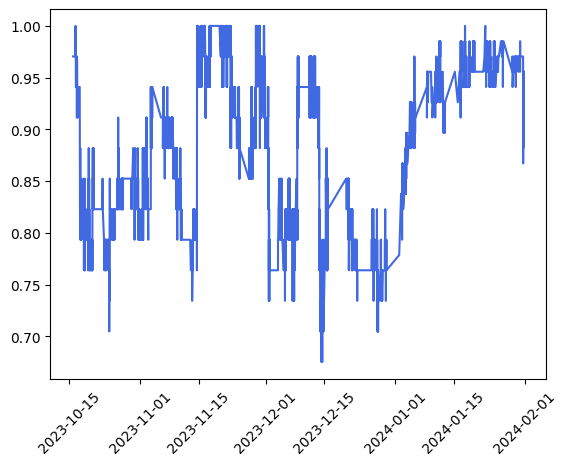

In [19]:
import matplotlib.pyplot as plt

plt.plot(imp_df_fil["time"],imp_df_fil['prob_no_change'], color='royalblue', linewidth=1.5)
plt.xticks(rotation=45)
plt.show()

## Export Data as CSV

In [20]:
import os
DATA_DIR = "../../data/processed/CME_implied_probabilities"
filename = "CME_IMP_JAN_2024.csv"
path = os.path.join(DATA_DIR, filename)
imp_df_fil.to_csv(path,index=False)